In [1]:
import torch.nn as nn
import torch
import json
from PIL import Image
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from datasets import Dataset

In [2]:
torch.set_default_dtype(torch.float32)

In [3]:
class MoondreamTextWrapper(nn.Module):
    def __init__(self, text_module_dict):
        super().__init__()
        self.blocks = text_module_dict['blocks']
        self.post_ln = text_module_dict['post_ln']
        self.lm_head = text_module_dict['lm_head']
        
        # FORCE everything to float32 for CPU training
        self.blocks.to(torch.float32)
        self.post_ln.to(torch.float32)
        self.lm_head.to(torch.float32)

    def forward(self, inputs_embeds, labels=None, attention_mask=None):
        # 1. Ensure input is float32
        x = inputs_embeds.to(torch.float32)
        
        for layer_item in self.blocks:
            if isinstance(layer_item, nn.ModuleDict):
                actual_layer = list(layer_item.values())[0]
                # 2. Ensure the layer itself is float32 before calling
                x = actual_layer.to(torch.float32)(x)
            else:
                x = layer_item.to(torch.float32)(x)
            
        x = self.post_ln.to(torch.float32)(x)
        logits = self.lm_head.to(torch.float32)(x)

        loss = None
        if labels is not None:
            # CrossEntropy expects Float32 logits but Long labels
            loss_fct = nn.CrossEntropyLoss()
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

        return {"loss": loss, "logits": logits}

In [4]:
model_id = "vikhyatk/moondream2"

# Load tokenizer and model strictly on CPU
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    trust_remote_code=True,
    dtype=torch.float32,  # Standard CPU precision
    device_map={"": "cpu"} # Force CPU
)

# Ensure the model is explicitly on CPU
model.to("cpu")
print("Model loaded successfully on CPU in Float32.")

Model loaded successfully on CPU in Float32.


In [5]:
model.model.vision.to(torch.float32)
model.model.vision.patch_emb.to(torch.float32)

Linear(in_features=588, out_features=1152, bias=True)

In [6]:
model.model._run_vision_encoder = torch.no_grad()(
    model.model._run_vision_encoder
)

In [7]:
_original_vis_enc = model.model._vis_enc

def _vis_enc_fp32(x):
    x = x.to(torch.float32)
    return _original_vis_enc(x)

model.model._vis_enc = _vis_enc_fp32

In [8]:
trainer_model = MoondreamTextWrapper(model.model.text)

In [9]:
with open(r"D:\Y4 Research\All_PNGS_dieatary\subset1_1_merged.json", "r") as f:
    data_list = json.load(f)

# Convert your JSON into a format the Trainer understands
def process_data(item):
    return {
        "image": item['image'],
        "question": item['qa'][0]['question'],
        "answer": item['qa'][0]['answer']
    }

formatted_data = [process_data(i) for i in data_list]
dataset = Dataset.from_list(formatted_data).train_test_split(test_size=0.1)

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

In [10]:
def collate_fn(batch):
    images, texts = [], []

    # ---------------------------
    # 1. Load images + build text
    # ---------------------------
    for item in batch:
        img = Image.open(item["image"]).convert("RGB")
        images.append(img)

        texts.append(
            f"Question: {item['question']}\nAnswer: {item['answer']}"
        )

    # ------------------------------------
    # 2. Image Embeddings (FORCED FLOAT32)
    # ------------------------------------
    processed_images = []

    with torch.no_grad():
        for img in images:
            # IMPORTANT: force float32 at encode time
            enc = model.encode_image(
                img,
                settings={"dtype": torch.float32}
            )

            # Handle Moondream cache structure
            if hasattr(enc, "caches") and len(enc.caches) > 0:
                tens = enc.caches[0]
                if isinstance(tens, (list, tuple)):
                    tens = tens[0]
            else:
                tens = enc

            # FINAL hard cast (safety net)
            processed_images.append(tens.to(torch.float32))

    image_embeds = torch.stack(processed_images)
    batch_size = image_embeds.shape[0]

    # Moondream outputs flattened vision tokens
    image_embeds = image_embeds.view(batch_size, -1, 2048)

    # ---------------------------
    # 3. Text Embeddings (FP32)
    # ---------------------------
    tokens_out = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    # Text embeddings from LM head weights (float32)
    text_embeds = (
        model.model.text.lm_head.weight
        .to(torch.float32)[tokens_out["input_ids"]]
    )

    # ---------------------------
    # 4. Concatenate vision + text
    # ---------------------------
    inputs_embeds = torch.cat(
        [image_embeds, text_embeds],
        dim=1
    )

    # ---------------------------
    # 5. Labels (mask vision tokens)
    # ---------------------------
    num_image_tokens = image_embeds.shape[1]

    image_label_pad = torch.full(
        (len(batch), num_image_tokens),
        -100,
        dtype=torch.long
    )

    labels = torch.cat(
        [image_label_pad, tokens_out["input_ids"]],
        dim=1
    )

    # ---------------------------
    # 6. Attention Mask
    # ---------------------------
    attention_mask = torch.ones(
        inputs_embeds.shape[:2],
        dtype=torch.long
    )

    return {
        "inputs_embeds": inputs_embeds,
        "labels": labels,
        "attention_mask": attention_mask,
    }


In [11]:
training_args = TrainingArguments(
    output_dir=r"D:\Y4 Research\Moondreams\v1",
    use_cpu=True,
    per_device_train_batch_size=1,
    remove_unused_columns=False,  # <--- THIS IS THE KEY
    fp16=False,
    logging_steps=1,
)

In [12]:
model.to("cpu")

HfMoondream(
  (model): MoondreamModel(
    (vision): ModuleDict(
      (patch_emb): Linear(in_features=588, out_features=1152, bias=True)
      (blocks): ModuleList(
        (0-26): 27 x ModuleDict(
          (ln1): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (attn): ModuleDict(
            (qkv): Linear(in_features=1152, out_features=3456, bias=True)
            (proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (ln2): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
          (mlp): ModuleDict(
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_features=4304, out_features=1152, bias=True)
          )
        )
      )
      (post_ln): LayerNorm((1152,), eps=1e-05, elementwise_affine=True)
      (proj_mlp): ModuleDict(
        (fc1): Linear(in_features=2304, out_features=8192, bias=True)
        (fc2): Linear(in_features=8192, out_features=2048, bias=True)
      )
    )
  

In [13]:
print([name for name, _ in model.named_children()])

['model']


In [14]:
print([name for name, _ in model.model.named_children()])

['vision', 'text', 'region']


In [15]:
from transformers import Trainer

trainer = Trainer(
    model=trainer_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
)

print("Starting training on CPU...")
trainer.train()

Starting training on CPU...


Step,Training Loss
1,45.299200
2,48.926600
3,44.657600
4,50.472900
5,44.325300
6,47.741800
7,48.741100
8,40.944800
9,45.446100
10,43.839500


TrainOutput(global_step=171, training_loss=35.972561306423614, metrics={'train_runtime': 3581.4107, 'train_samples_per_second': 0.048, 'train_steps_per_second': 0.048, 'total_flos': 0.0, 'train_loss': 35.972561306423614, 'epoch': 3.0})

In [32]:

model.model.text.blocks.load_state_dict(
    trainer_model.blocks.state_dict()
)

model.model.text.post_ln.load_state_dict(
    trainer_model.post_ln.state_dict()
)

model.model.text.lm_head.load_state_dict(
    trainer_model.lm_head.state_dict()
)

print("✅ Trained text weights merged into base Moondream model")


✅ Trained text weights merged into base Moondream model


In [33]:
FULL_MODEL_PATH = r"C:\Models\Moondream"

model.save_pretrained(FULL_MODEL_PATH)
tokenizer.save_pretrained(FULL_MODEL_PATH)

print(f"🎉 Full Moondream model saved to {FULL_MODEL_PATH}")


🎉 Full Moondream model saved to C:\Models\Moondream


In [16]:
# Save the final version to a dedicated folder
final_path = r"D:\Y4 Research\Moondreams\v1\Model"

trainer.save_model(final_path)
tokenizer.save_pretrained(final_path)

print(f"Final research model saved to {final_path}")

Final research model saved to D:\Y4 Research\Moondreams\v1\Model


Evaluation

In [17]:
import torch
from tqdm import tqdm

def generate_eval_report(trainer, eval_dataset):
    trainer_model.eval()
    results = []
    
    print("Generating predictions for evaluation...")
    for i in tqdm(range(len(eval_dataset))):
        item = eval_dataset[i]
        
        # Prepare input using your existing collate logic
        batch = collate_fn([item])
        inputs_embeds = batch["inputs_embeds"].to("cpu")
        
        # Generate output
        with torch.no_grad():
            outputs = trainer_model(inputs_embeds=inputs_embeds)
            logits = outputs["logits"]
            predicted_ids = torch.argmax(logits, dim=-1)
            
            # Decode the text
            prediction = tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
            # We only want the part after "Answer:" 
            actual_answer = prediction.split("Answer:")[-1].strip() if "Answer:" in prediction else prediction
            
        results.append({
            "image": item["image"],
            "ground_truth": item["answer"],
            "prediction": actual_answer
        })
    return results

eval_results = generate_eval_report(trainer, eval_dataset)

Generating predictions for evaluation...


100%|██████████| 7/7 [02:25<00:00, 20.75s/it]


In [21]:
from evaluate import load

def calculate_metrics(results):
    rouge = load("rouge")
    bleu = load("bleu")

    predictions = [r["prediction"] for r in results]
    references = [r["ground_truth"] for r in results]

    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references
    )

    bleu_score = bleu.compute(
        predictions=predictions,
        references=references
    )

    # 🎯 Select only major, meaningful metrics
    metrics = {
        "ROUGE-1 (F1)": round(rouge_scores["rouge1"], 4),
        "ROUGE-2 (F1)": round(rouge_scores["rouge2"], 4),
        "ROUGE-L (F1)": round(rouge_scores["rougeL"], 4),
        "BLEU": round(bleu_score["bleu"], 4),
    }

    return metrics


# ---- Run evaluation ----
metrics = calculate_metrics(eval_results)

print("\n📊 Evaluation Metrics")
print("-" * 30)
for k, v in metrics.items():
    print(f"{k:<15}: {v}")



📊 Evaluation Metrics
------------------------------
ROUGE-1 (F1)   : 0.9265
ROUGE-2 (F1)   : 0.8465
ROUGE-L (F1)   : 0.9266
BLEU           : 0.8862


In [24]:
%matplotlib inline

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
def plot_loss_curve(trainer):
    """
    Plots training (and optional evaluation) loss from HuggingFace Trainer logs.
    Displays inline in Jupyter and saves a high-resolution image.
    """

    # Convert Trainer log history to DataFrame
    history = trainer.state.log_history
    df = pd.DataFrame(history)

    plt.figure(figsize=(10, 6))

    # -----------------------------
    # Training Loss
    # -----------------------------
    if "loss" in df.columns:
        train_loss = df[df["loss"].notna()]
        plt.plot(
            train_loss["step"],
            train_loss["loss"],
            label="Training Loss",
            linewidth=2
        )

    # -----------------------------
    # Evaluation Loss (Optional)
    # -----------------------------
    if "eval_loss" in df.columns:
        eval_loss = df[df["eval_loss"].notna()]
        if not eval_loss.empty:
            plt.plot(
                eval_loss["step"],
                eval_loss["eval_loss"],
                label="Evaluation Loss",
                linestyle="--",
                marker="o"
            )

    # -----------------------------
    # Styling
    # -----------------------------
    plt.title("Moondream Training Progress: Loss vs Steps", fontsize=14)
    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel("Loss (Cross-Entropy)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    # -----------------------------
    # Save for report / thesis
    # -----------------------------
    plt.savefig(
        r"D:\Y4 Research\Moondreams\v1\loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inline in Jupyter
    plt.show()


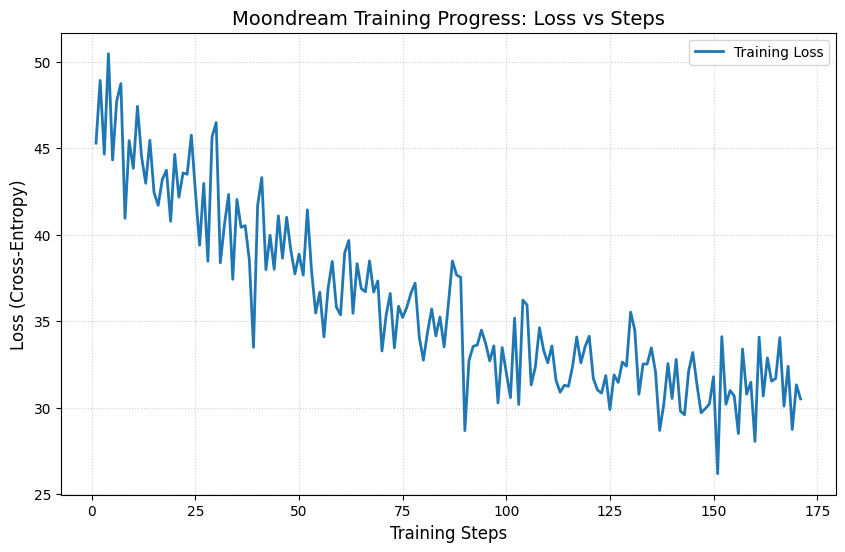

In [27]:
plot_loss_curve(trainer)

In [29]:
import pandas as pd

# 1. Save detailed predictions to CSV
df = pd.DataFrame(eval_results)
df.to_csv(
    r"D:\Y4 Research\Moondreams\v1\evaluation_report.csv",
    index=False
)

# 2. Write summary report
with open(r"D:\Y4 Research\Moondreams\v1\summary_report.txt", "w") as f:
    f.write("DIETARY MODEL EVALUATION REPORT\n")
    f.write("=" * 35 + "\n\n")

    f.write(f"ROUGE-1 (F1): {metrics['ROUGE-1 (F1)']:.4f}\n")
    f.write(f"ROUGE-2 (F1): {metrics['ROUGE-2 (F1)']:.4f}\n")
    f.write(f"ROUGE-L (F1): {metrics['ROUGE-L (F1)']:.4f}\n")
    f.write(f"BLEU Score  : {metrics['BLEU']:.4f}\n\n")

    f.write("Sample Predictions:\n")
    f.write("-" * 35 + "\n")

    for res in eval_results[:5]:
        f.write(f"Target     : {res['ground_truth']}\n")
        f.write(f"Prediction : {res['prediction']}\n")
        f.write("-" * 35 + "\n")


In [1]:
import json

def infer_image_to_json(
    image_path,
    question,
    model,
    trainer_model,
    tokenizer
):
    trainer_model.eval()

    # ---------------------------------
    # 1. Load image
    # ---------------------------------
    img = Image.open(image_path).convert("RGB")

    # ---------------------------------
    # 2. Build pseudo-batch (reuse collate_fn logic)
    # ---------------------------------
    batch = collate_fn([{
        "image": image_path,
        "question": question,
        "answer": ""   # empty because this is inference
    }])

    inputs_embeds = batch["inputs_embeds"].to("cpu")

    # ---------------------------------
    # 3. Forward pass
    # ---------------------------------
    with torch.no_grad():
        outputs = trainer_model(inputs_embeds=inputs_embeds)
        logits = outputs["logits"]

        # Token prediction
        predicted_ids = torch.argmax(logits, dim=-1)

    # ---------------------------------
    # 4. Decode output text
    # ---------------------------------
    decoded_text = tokenizer.decode(
        predicted_ids[0],
        skip_special_tokens=True
    )

    # ---------------------------------
    # 5. Extract JSON from model output
    # ---------------------------------
    try:
        json_start = decoded_text.find("{")
        json_end = decoded_text.rfind("}") + 1
        json_output = json.loads(decoded_text[json_start:json_end])
    except Exception:
        json_output = {
            "raw_output": decoded_text,
            "error": "JSON parsing failed"
        }

    return json_output


In [2]:
image_path = r"D:\Y4 Research\All_PNGS_dieatary\subset1\925.png"

question = (
    "Extract the product name, brand, serving size, "
    "ingredients, nutrient facts, and health claims in JSON format."
)

output_json = infer_image_to_json(
    image_path=image_path,
    question=question,
    model=model,
    trainer_model=trainer_model,
    tokenizer=tokenizer
)

print(json.dumps(output_json, indent=2))


NameError: name 'model' is not defined